In [1]:
# Dependencies and imports
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from util.plotters import plot_config
from util.dml import run_analysis, plot_results, extract_evaluation_table, plot_eval_metrics
from util.power import simulated_power_curve, interpolate_mde, plot_power_curve, simulate_dgp_margins, simulate_dgp_observed


plot_config()

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

Using default theme


/var/folders/xn/6vg5ddx11lbdhtrbqtyh_x600000gn/T/ipykernel_69408/1308625586.py:58: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['home_damage'] = df['home_damage'].replace({


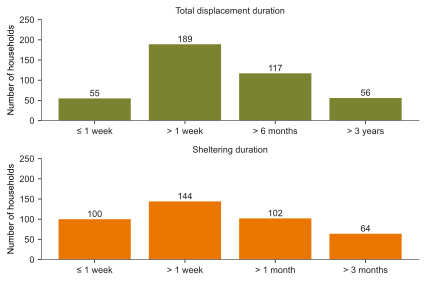

In [2]:
# Organize outcome, treatment, and covariate variables
DAYS_IN_MONTH = 30.437

# Read parsed and anonymized data
data_path = os.path.join("data", 'sample.pkl')
df = pd.read_pickle(data_path)
df.head(5)

# Total displacement durations
otype = "total"
OUTCOME_BINS = {
    '≤ 1 week': 7,
    '> 1 week': 7,
    '> 6 months': DAYS_IN_MONTH * 6,
    '> 3 years': DAYS_IN_MONTH * 36,
}
OUTCOME_LEVELS_T = [otype + '-' + k for k in list(OUTCOME_BINS.keys())]
for outcome in OUTCOME_BINS:
    outcome_label = otype + '-' + outcome
    df[outcome_label] = 0
    threshold = OUTCOME_BINS[outcome]
    is_first_bin = outcome_label == OUTCOME_LEVELS_T[0]
    mask = df[f'duration_{otype}'] * DAYS_IN_MONTH <= threshold if is_first_bin else df[f'duration_{otype}'] * DAYS_IN_MONTH > threshold
    df.loc[mask, outcome_label] = 1

# Emergency displacement durations
otype = "emergency"
OUTCOME_BINS = {
    '≤ 1 week': 7,
    '> 1 week': 7,
    '> 1 month': DAYS_IN_MONTH,
    '> 3 months': DAYS_IN_MONTH * 3,
}
OUTCOME_LEVELS_E = [otype + '-' + k for k in list(OUTCOME_BINS.keys())]
for outcome in OUTCOME_BINS:
    outcome_label = otype + '-' + outcome
    df[outcome_label] = 0
    threshold = OUTCOME_BINS[outcome]
    is_first_bin = outcome_label == OUTCOME_LEVELS_E[0]
    mask = df[f'duration_{otype}'] * DAYS_IN_MONTH <= threshold if is_first_bin else df[f'duration_{otype}'] * DAYS_IN_MONTH > threshold
    df.loc[mask, outcome_label] = 1


COVARIATES = [
    'home_damage', 'comm_damage',
    'bin_land_tenure', 'bin_dwell_tenure',
    'structure-concrete_heavy', 'structure-wood_light', 'structure-wood_heavy', 'housing_quality',
    'any_fatality', 'any_injury',
    'hazard_type-earthquake_only', 'hazard_type-tsunami', 'hazard_type-liquefaction',#
    'bin_income', 'edu_household', 
    'bin_household_size', 'elderly', 'children',
    'occupation-agricultural', 'occupation-business', 'occupation-employment', 
    'place_identified', 'place_dependent', 'hometown',
    'aspiration_stay',
]

# Merge home damage categories
df['home_damage'] = df['home_damage'].replace({
    '(45-65%) Heavy damage': '(>45%) Destroyed',
    '(>65%) Completely lost': '(>45%) Destroyed'
})
df['home_damage'] = df['home_damage'].cat.set_categories([
    '(<30%) Minor damage',
    '(30-45%) Moderate damage',
    '(>45%) Destroyed'
], ordered=True)

TREATMENTS = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
    'hazard_type-earthquake_only', 'hazard_type-tsunami', 'hazard_type-liquefaction'] # NOTE: These are all related to disaster impact and so need to consider role of time in identification

# Add new treatments (hot-encoded)
base_vars = ['home_damage', 'comm_damage', 'tenure_duration', 'bin_income', 'bin_household_size', 'edu_household', "bin_land_tenure", "bin_dwell_tenure"]
for base_var in base_vars:
    var_opt = list(df[base_var].cat.categories)
    treatments = [base_var + '-' + opt for opt in var_opt]
    for i in range(len(var_opt)):
        idx = df[base_var] == var_opt[i]
        df[treatments[i]] = 0
        df.loc[idx, treatments[i]] = 1
        TREATMENTS.append(treatments[i])

all_cols = list(set(OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + TREATMENTS + COVARIATES))
data = df.copy()
for col in data.columns:
    if data[col].dtype == 'category':
        if (len(data[col].cat.categories) == 2) and (data[col].cat.categories == ['Yes', 'No']).all():
            data[col] = data[col].apply(lambda x: 1 if x == 'Yes' else 0).astype(float)
        else:
            data[col] = data[col].cat.codes
    elif data[col].dtype == 'bool':
        data[col] = data[col].astype(int)

# Collect frequencies of total and emergency duration bins
freq_total = [df[col].sum() for col in OUTCOME_LEVELS_T]
freq_emergency = [df[col].sum() for col in OUTCOME_LEVELS_E]

# Define labels
labels_total = [k.replace('total-', '') for k in OUTCOME_LEVELS_T]
labels_emergency = [k.replace('emergency-', '') for k in OUTCOME_LEVELS_E]

# Define colors
total_colors = ["#d8d6cc", "#c1c78a", "#7b8230", "#3f4625"]
shelter_colors = ["#e7d3ba", "#f5ab5e", "#ea7600", "#733c1c"]

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=False, sharey=True)

# Total duration subplot (green)
axs[0].bar(labels_total, freq_total, color=total_colors[-2])
axs[0].set_title('Total displacement duration')
axs[0].set_ylabel('Number of households')
for i, count in enumerate(freq_total):
    axs[0].text(i, count + 1, f'{int(count)}', ha='center', va='bottom')

# Emergency duration subplot (orange)
axs[1].bar(labels_emergency, freq_emergency, color=shelter_colors[-2])
axs[1].set_title('Sheltering duration')
axs[1].set_ylabel('Number of households')
axs[1].set_xlabel(None)
for i, count in enumerate(freq_emergency):
    axs[1].text(i, count + 1, f'{int(count)}', ha='center', va='bottom')
axs[1].set_ylim((0, 250))

# For outputs
img_folder = "img"
output_total = {}
output_shelter = {}

# Improve layout
plt.tight_layout()
plt.show()

# Identification

[DAGgity.net](https://www.dagitty.net/) was used to draw causal diagrams and identify adjustment sets. Domain knowledge from literature review on household displacement and return in disasters was used to design the survey (and thus to measure relevant variables), as well as the likely associations between the relevant variables.

## Home damage

Identification is fot a *total effect*. Given the high correlation between home damage and community damage, a measure of the *direct effect* is likely to be unreliable. Essentially, it is not possible to separate the two with our data.

A minimal adjustment set includes four variables: hazard exposure, livelihood type, household income, and tenure status.

<img src="dag/home_damage.png" width="600"> <img src="dag/legend.png" width="200">


# Estimation

Estimation was performed using debiased/double machine learning.

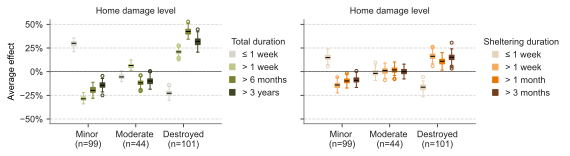

In [3]:
base_var = 'home_damage'
display_name = 'Home damage level'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]

# Total effect
X = [
'hazard_type-tsunami', 'hazard_type-liquefaction', 'hazard_type-earthquake_only', # hazard exposure
'occupation-agricultural', 'occupation-business', 'occupation-employment', # livelihood type
'bin_income', # household income
'bin_land_tenure', 'bin_dwell_tenure', # tenure status
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = run_analysis(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = run_analysis(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

ylim=(-.55, .55)

fig, axes = plt.subplots(1, 2, figsize=(8, 2.25), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration', y_lims=ylim)
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration', y_lims=ylim)
axes[0].set_title(display_name)
axes[0].set_ylabel('Average effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

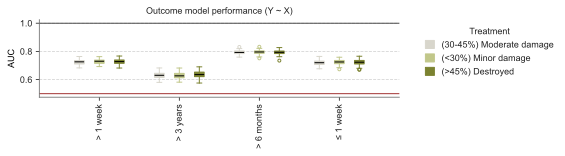

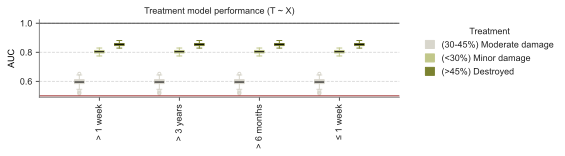

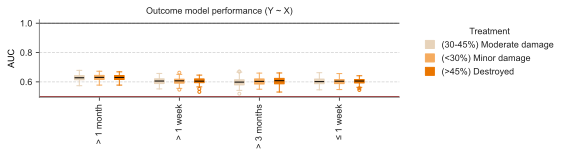

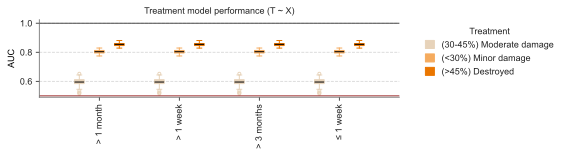

In [4]:
display_name = 'Home damage level'

eval_total = extract_evaluation_table(output_total[display_name])

plot_eval_metrics(eval_total, metric='eval_Y', title='Outcome model performance (Y ~ X)', ylabel='AUC', colors=total_colors)
plot_eval_metrics(eval_total, metric='eval_T', title='Treatment model performance (T ~ X)', ylabel='AUC', colors=total_colors)

eval_emergency = extract_evaluation_table(output_shelter[display_name])

plot_eval_metrics(eval_emergency, metric='eval_Y', title='Outcome model performance (Y ~ X)', ylabel='AUC', colors=shelter_colors)
plot_eval_metrics(eval_emergency, metric='eval_T', title='Treatment model performance (T ~ X)', ylabel='AUC', colors=shelter_colors)

# Sensitivity

E-values represent the minimum confounding risk ratios (RRs) that uncontrolled confounder(s) would need to have with both exposure and outcome to fully explain away the observed effect (i.e., to have no causal effect). It is calculated as follows:

E-value = RR+ sqrt[RR*(RR-1)] for RR>1

References:
- VanderWeele TJ & Din P (2017). Sensitivity analysis in nonrandomized research: Introducing the E-Value. *Annals of Internal Medicine*.
- Din P & VanderWeele TJ (2016). Sensitivity analysis without assumptions. *Epidemiology*.
- VanderWeele TJ & Mathur MB (2020). Commentary: Developing best-practice guidelines for the reporting of E-values. *International Journal of Epidemiology*.

However, the average treatment effects (ATEs) calculated previously are comparable to risk differences (RDs). So, first I need to convert from RD to RR:

RR = p1/p0
RD = p1 - p0
RR = 1 + (RD/p0)

In this case, p1 represents E[Y|T=1] and p0 represents E[Y|T=0].

In [5]:
treatment = 'Home damage level'
cols = ['treatment', 'outcome','rd_median', 'rr_median', 'e_point', 'e_ci']


total_res = output_total[treatment].copy()
total_res.treatment = total_res.treatment.str.split('-', n=1).str[1]
total_res.outcome = total_res.outcome.str.replace('-',' ')
shelter_res = output_shelter[treatment].copy()
shelter_res.treatment = shelter_res.treatment.str.split('-', n=1).str[1]
shelter_res.outcome = shelter_res.outcome.str.replace('emergency-','shelter ')

def mask_format(row):
    if row['sig95']:
        return ["font-weight: bold; color: yellow"] * len(row)
    else:
        return [""] * len(row)


print(f"EFFECT OF [{treatment}] ON TOTAL DISPLACEMENT DURATION")

total_table = (
    total_res.loc[:, cols + ['sig95']].set_index(['treatment', 'outcome'])
    .style
    .format('{:.2f}')
    .apply(mask_format, axis=1)
    .hide(subset=['sig95'], axis=1)
)
display(total_table)

print(f"EFFECT OF [{treatment}] ON SHELTERED DISPLACEMENT DURATION")

shelter_table = (
    shelter_res.loc[:, cols + ['sig95']].set_index(['treatment', 'outcome'])
    .style
    .format('{:.2f}')
    .apply(mask_format, axis=1)
    .hide(subset=['sig95'], axis=1)
)
display(shelter_table)

EFFECT OF [Home damage level] ON TOTAL DISPLACEMENT DURATION


EFFECT OF [Home damage level] ON SHELTERED DISPLACEMENT DURATION


# Power

Target margins
using DGP = <function simulate_dgp_margins at 0x120e59800>

 θ (input)    true ATE     power     mean θ̂
─--------------------------------------------------------------------------
      0.05      0.0498     0.520      0.0622   
      0.10      0.0993     0.730      0.1173   
      0.15      0.1484     0.820      0.1678  ✓
      0.20      0.1974     0.920      0.2255  ✓
      0.25      0.2463     0.980      0.2721  ✓
      0.30      0.2951     1.000      0.3172  ✓
MDE at 80% power : 0.138

Observed
using DGP = <function simulate_dgp_observed at 0x120e598a0>

 θ (input)    true ATE     power     mean θ̂
─--------------------------------------------------------------------------
      0.05      0.0494     0.440      0.0639   
      0.10      0.0981     0.610      0.1104   
      0.15      0.1463     0.730      0.1578   
      0.20      0.1941     0.910      0.1971  ✓
      0.25      0.2419     0.970      0.2419  ✓
      0.30      0.2894     0.990      0.2941  ✓
MDE at 80% 

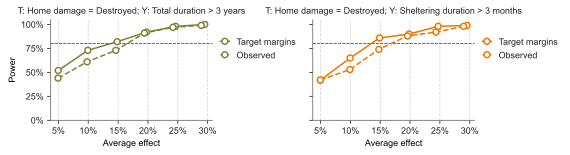

,DGP,Outcome set,Treatment,MDE
0,Target margins,Total duration > 3 years,Home damage = Destroyed,0.137506
1,Observed,Total duration > 3 years,Home damage = Destroyed,0.164865
2,Target margins,Sheltering duration > 3 months,Home damage = Destroyed,0.134959
3,Observed,Sheltering duration > 3 months,Home damage = Destroyed,0.168330


In [7]:
DGPS = {
    'Target margins': simulate_dgp_margins,
    'Observed': simulate_dgp_observed,
}


EFFECT_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
S_OUTER = 100

T = 'home_damage-(>45%) Destroyed'
Ys = ['total-> 3 years', 'emergency-> 3 months']

T_label = T.split('-')[0].replace('_', ' ').capitalize() + ' = ' + T.split('-')[1].split(' ')[1].capitalize()
Y_labels = [y.replace('-', ' ').replace('total','Total duration').replace('emergency', 'Sheltering duration') for y in Ys]

colors = [total_colors, shelter_colors]
linestyles = ['solid', 'dashed']

fig, axs = plt.subplots(1, 2, figsize=(8, 2.25), sharex=True, sharey=True)

mde_records = []

for i, Y in enumerate(Ys):
    for j, dgp in enumerate(DGPS):
        print(dgp)
        powers, mean_ates, mean_thetas = simulated_power_curve(data[T], data[Y], data[X], EFFECT_GRID, S_OUTER, dgp=DGPS[dgp], verbose=True)
        mde = interpolate_mde(mean_ates, powers, verbose=True)
        plot_power_curve(mean_ates, powers, axs[i], label=dgp, color=colors[i][-2], linestyle=linestyles[j])
        axs[i].set_title(f'T: {T_label}; Y: {Y_labels[i]}')
        # Record MDE for summary table
        mde_records.append({
            'DGP':          dgp,
            'Outcome set':  Y_labels[i],
            'Treatment':    T_label,
            'MDE':          mde,
        })
axs[1].set_ylabel(None)
fig.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_power_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

pd.DataFrame(mde_records)